In [84]:
import napari
import pandas as pd
import seaborn as sns

In [2]:
viewer = napari.Viewer()
viewer.show()

/home/nickdg/Documents/testPixiEnv/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:602: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/home/nickdg/Documents/testPixiEnv/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:636: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/home/nickdg/Documents/testPixiEnv/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:1746: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts
/home/nickdg/Documents/testPixiEnv/.pixi/envs/default/lib/python3.13/site-packages/owncloud/owncloud.py:1766: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts
/home/nickdg/Documents/testPixiEnv/.pixi/envs/default/lib/python3.13/site-packages/ownclou

In [8]:
from tifffile import imread

In [12]:
stack = imread('multi_cell.tif')
viewer.add_image(data=stack, name='calcium_imaging')

<Image layer 'calcium_imaging' at 0x7f4d0c7712b0>

In [13]:
import numpy as np

In [14]:
stack.shape

(2000, 60, 80)

In [16]:
labels = np.zeros(stack.shape[1:], dtype=np.uint8)
viewer.add_labels(data=labels, name='cell_labels')

<Labels layer 'cell_labels' at 0x7f4d36a34ec0>

In [19]:
labels = viewer.layers['cell_labels']

In [22]:
labels.save('cell_labels.tif')

['cell_labels.tif']

In [25]:
import matplotlib.pyplot as plt

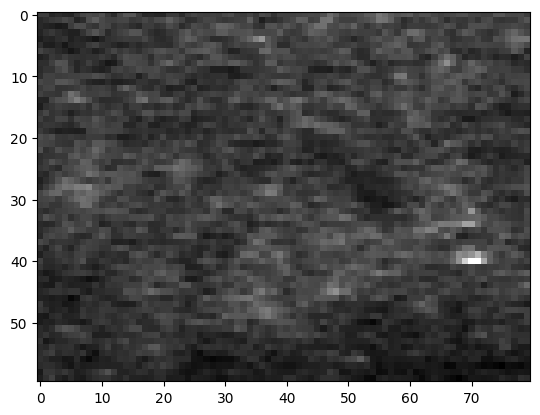

In [36]:
frames = imread('multi_cell.tif')
frame_id = 100
plt.imshow(frames[frame_id], cmap='gray');

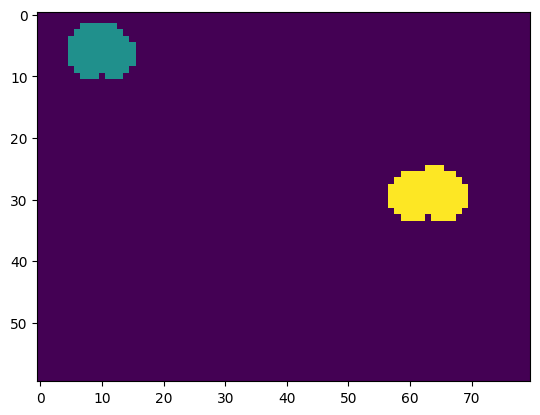

In [37]:
labels = imread('cell_labels.tif')
plt.imshow(labels, cmap='viridis')

In [81]:
traces = np.array([frames[:, labels==id].mean(1) for id in np.unique(labels)])
cell_activity = pd.DataFrame(traces.T).rename_axis(index='Frame').melt(var_name='Cell', value_name='Mean', ignore_index=False).reset_index()
cell_activity.head(10)

,Frame,Cell,Mean
0,0,0,1298.714687
1,1,0,1206.809215
2,2,0,1179.668397
3,3,0,1164.566299
4,4,0,1172.994376
5,5,0,1177.964093
6,6,0,1205.629461
7,7,0,1199.072464
8,8,0,1193.677050
9,9,0,1215.726368


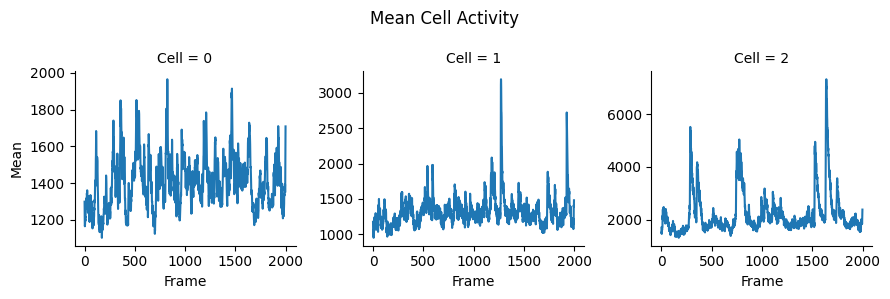

In [99]:
g = sns.FacetGrid(data=cell_activity, col='Cell', col_wrap=3, sharey=False, sharex=True)
g.map_dataframe(sns.lineplot, x='Frame', y='Mean');
plt.suptitle('Mean Cell Activity')
g.tight_layout();
g.savefig('results.png');


In [ ]:
from brainglobe_atlasapi.bg_atlas import BrainGlobeAtlas
atlas = BrainGlobeAtlas("allen_mouse_25um")

from tifffile import imwrite
imwrite('mouse_atlas.tif', atlas.reference)